# Exploratory Data Analysis: Airbnb New York 2019

## Step 1: Problem statement and data loading
Study the variables of the NYC Airbnb 2019 listings to understand the dataset
before modelling. The goal of this notebook is to clean the data, explore each
variable, find relationships (mainly with `price`) and save a processed dataset.

In [1]:
import pandas as pd

total_data = pd.read_csv("../data/raw/AB_NYC_2019.csv")
print(total_data.shape)
total_data.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
# Data types and non-null values
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## Step 2: Exploration and data cleaning

The dataset has 48,895 rows and 16 columns: 7 integer, 3 float and 6 text variables.
`last_review` and `reviews_per_month` share the same 10,052 null values (listings
without any review), while `name` and `host_name` have only a handful.

#### Eliminate duplicates
We ignore `id`, because it is unique per listing and would hide repeated rows.

In [3]:
total_data.drop("id", axis = 1).duplicated().sum()

np.int64(0)

In [4]:
if total_data.drop("id", axis = 1).duplicated().sum():
    total_data = total_data.drop_duplicates(subset = total_data.columns.difference(["id"]))
print(total_data.shape)

(48895, 16)


#### Eliminate irrelevant information
`id` and `host_id` are identifiers, `name` and `host_name` are free text, and
`last_review` is a date that is already summarised by `number_of_reviews` and
`reviews_per_month` (and has 10,052 nulls). We remove them before the feature
selection phase.

In [5]:
total_data.drop(["id", "name", "host_id", "host_name", "last_review"], axis = 1, inplace = True)
total_data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


### Step 3: Analysis of univariate variables

#### Analysis of categorical variables
`neighbourhood_group` and `room_type` have few categories, so we plot them directly.
`neighbourhood` has around 220 distinct values and is left out of the plots; we will
decide how to treat it in the feature engineering step.

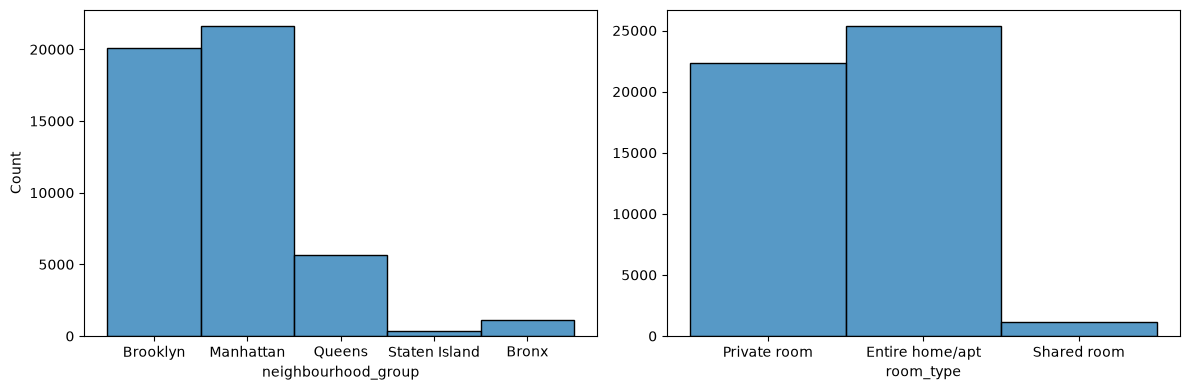

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(1, 2, figsize = (12, 4))

sns.histplot(ax = axis[0], data = total_data, x = "neighbourhood_group")
sns.histplot(ax = axis[1], data = total_data, x = "room_type").set_ylabel(None)

plt.tight_layout()
plt.show()

#### Analysis on numeric variables
For every numeric variable we show the histogram together with its boxplot.
`latitude` and `longitude` are coordinates and are left for the multivariate analysis.

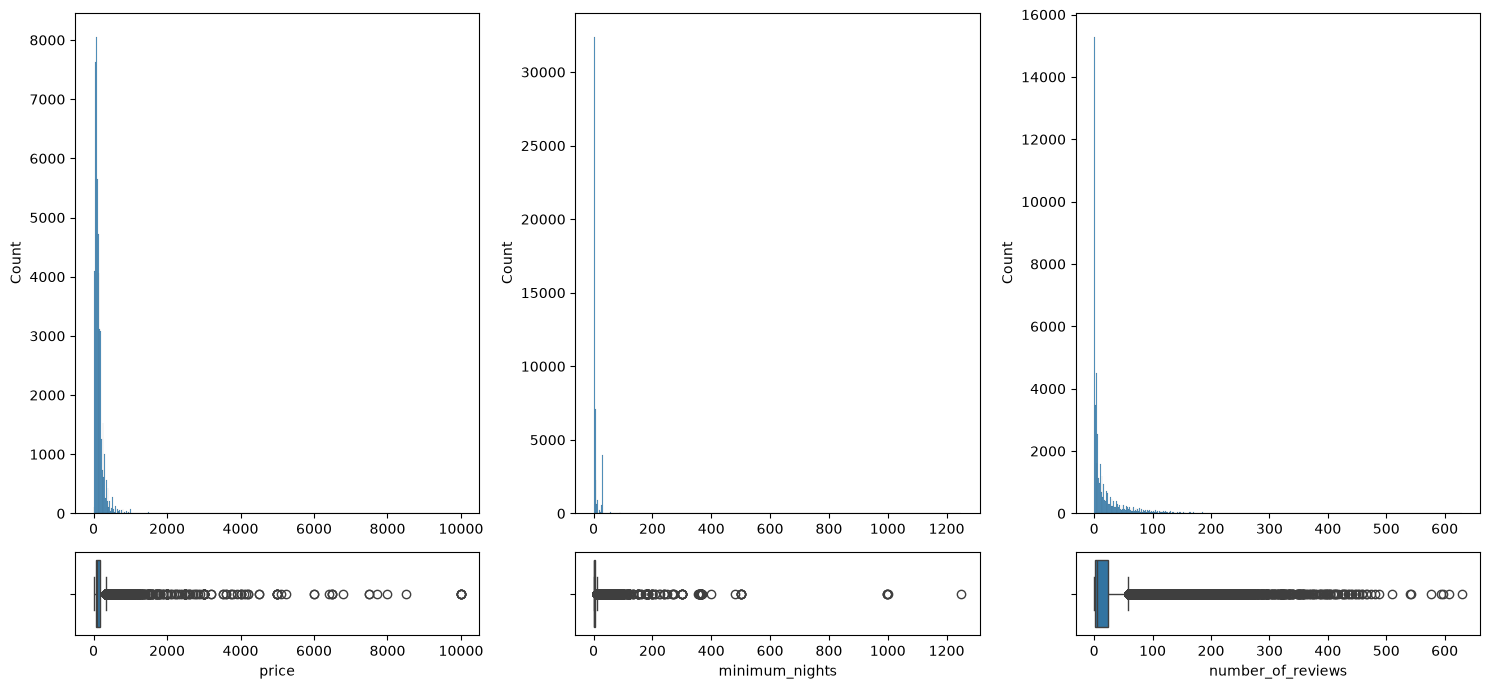

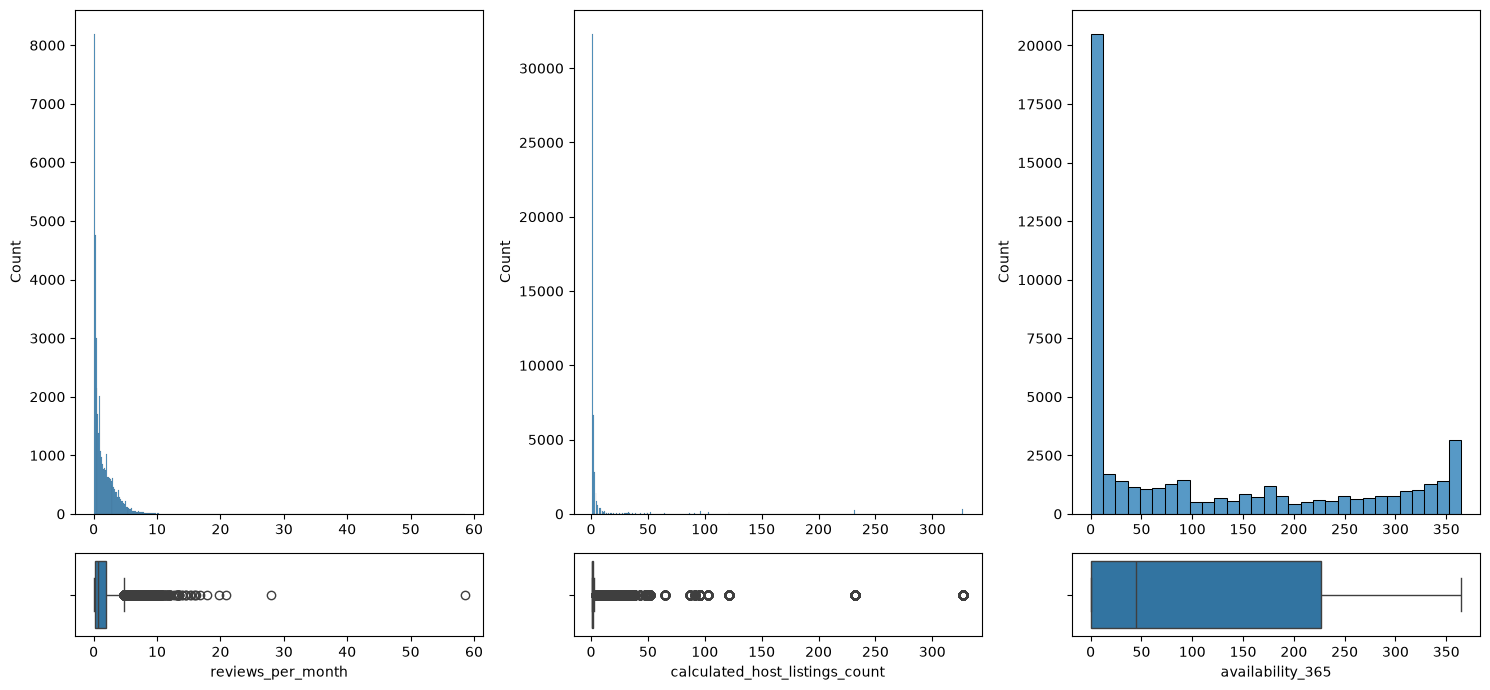

In [7]:
def plot_numeric(variables):
    fig, axis = plt.subplots(2, len(variables), figsize = (15, 7), gridspec_kw = {"height_ratios": [6, 1]})
    for i, variable in enumerate(variables):
        sns.histplot(ax = axis[0, i], data = total_data, x = variable).set_xlabel(None)
        sns.boxplot(ax = axis[1, i], data = total_data, x = variable)
    plt.tight_layout()
    plt.show()

plot_numeric(["price", "minimum_nights", "number_of_reviews"])
plot_numeric(["reviews_per_month", "calculated_host_listings_count", "availability_365"])

In [8]:
total_data[["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]].describe().round(2)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.00,48895.00,48895.00,38843.00,48895.00,48895.00
mean,152.72,7.03,23.27,1.37,7.14,112.78
std,240.15,20.51,44.55,1.68,32.95,131.62
min,0.00,1.00,0.00,0.01,1.00,0.00
25%,69.00,1.00,1.00,0.19,1.00,0.00
50%,106.00,3.00,5.00,0.72,1.00,45.00
75%,175.00,5.00,24.00,2.02,2.00,227.00
max,10000.00,1250.00,629.00,58.50,327.00,365.00


#### Conclusions of the univariate analysis

- **Boroughs:** Manhattan (21,661) and Brooklyn (20,104) hold about 85% of the
  listings. Queens, the Bronx and Staten Island together have only 7,130.
- **Room types:** Entire home/apt (25,409) and Private room (22,326) make up about
  98% of the dataset. Shared rooms are rare (1,160).
- **price:** very right-skewed (skewness 19.1). The median is 106 but the mean is
  152.7 and the maximum is 10,000. There are 1,044 listings above 500 and 11 listings
  with a price of 0, which look like errors. This variable needs outlier treatment.
- **minimum_nights:** the median is 3 nights, but the maximum is 1,250 and 747
  listings ask for more than 30 nights, which suggests long-term rentals rather
  than short stays. It is also strongly skewed (21.8).
- **number_of_reviews and reviews_per_month:** both right-skewed (3.7 and 3.1).
  10,052 listings (about 21%) have no reviews, and they are exactly the nulls of
  `reviews_per_month`.
- **calculated_host_listings_count:** the median is 1 and the maximum is 327, so most
  hosts have a single listing while a few professional hosts manage hundreds.
- **availability_365:** the least skewed variable (0.8), but 17,533 listings
  (36%) have 0 available days, so they cannot be booked during the year.

### Step 4: Analysis of multivariate variables

#### Categorical - categorical analysis
We check how the room types are distributed across the boroughs.

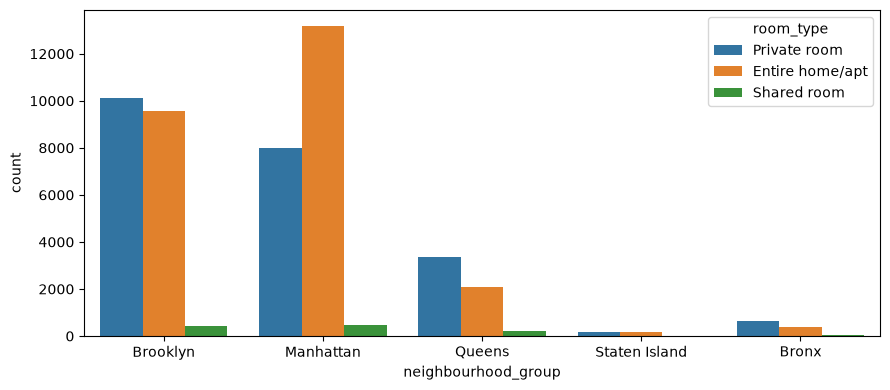

In [9]:
fig, axis = plt.subplots(figsize = (9, 4))

sns.countplot(ax = axis, data = total_data, x = "neighbourhood_group", hue = "room_type")

plt.tight_layout()
plt.show()

In [10]:
pd.crosstab(total_data["neighbourhood_group"], total_data["room_type"], normalize = "index").round(3)

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,0.347,0.598,0.055
Brooklyn,0.475,0.504,0.021
Manhattan,0.609,0.368,0.022
Queens,0.370,0.595,0.035
Staten Island,0.472,0.504,0.024


#### Numerical - numerical analysis
Correlation matrices of the numeric variables. Pearson measures linear relationships
and is sensitive to outliers; Spearman works on ranks and is more robust for the
very skewed variables of this dataset, so we show both.

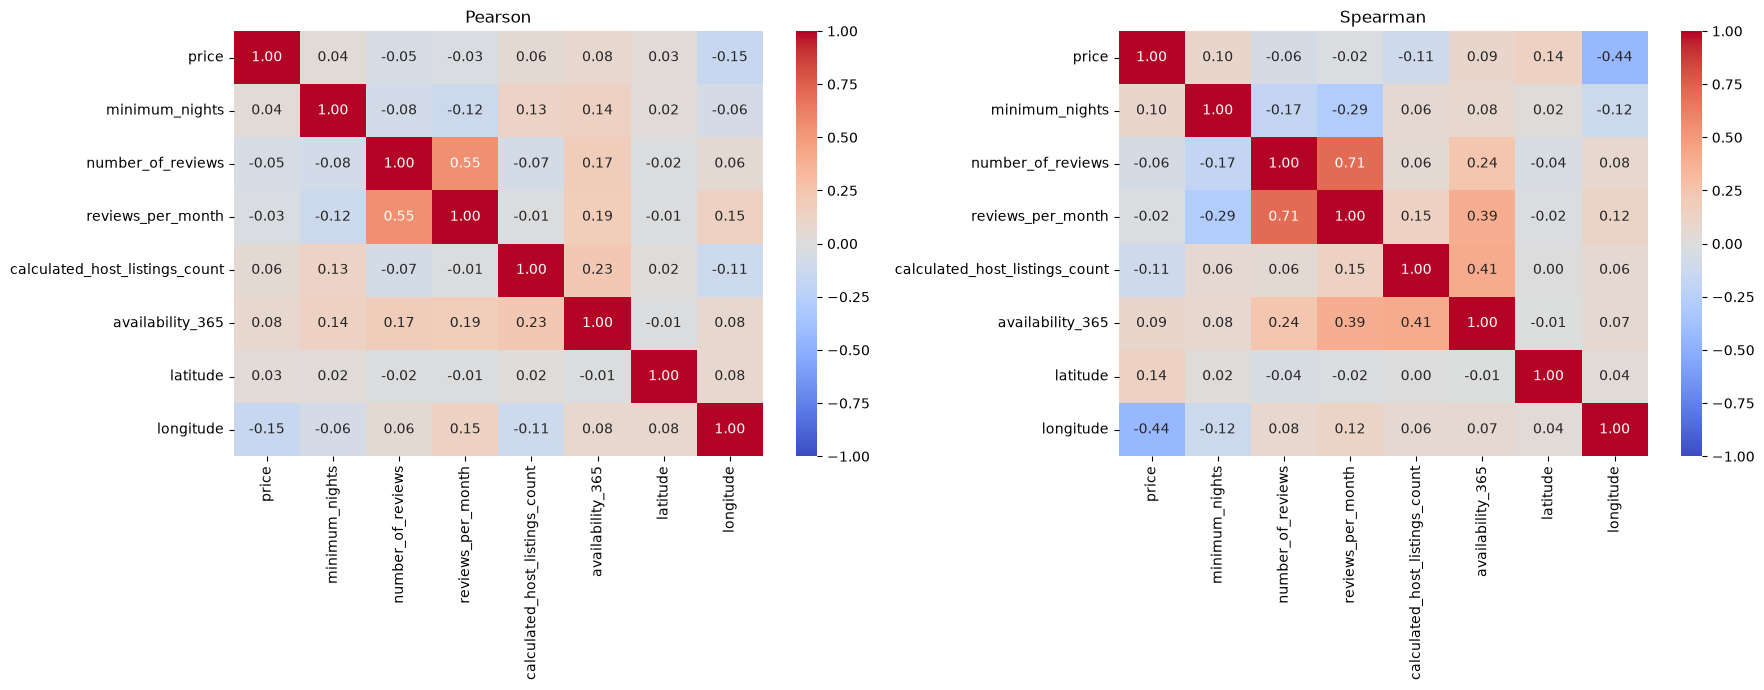

In [11]:
numeric_variables = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365", "latitude", "longitude"]

fig, axis = plt.subplots(1, 2, figsize = (18, 7))

sns.heatmap(total_data[numeric_variables].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1, ax = axis[0]).set_title("Pearson")
sns.heatmap(total_data[numeric_variables].corr(method = "spearman"), annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1, ax = axis[1]).set_title("Spearman")

plt.tight_layout()
plt.show()

#### Numerical - categorical analysis
Price by borough and by room type. The y axis is limited to 500 only to make the boxes
readable (it hides the 1,044 listings above 500 in the plot); no data is removed.

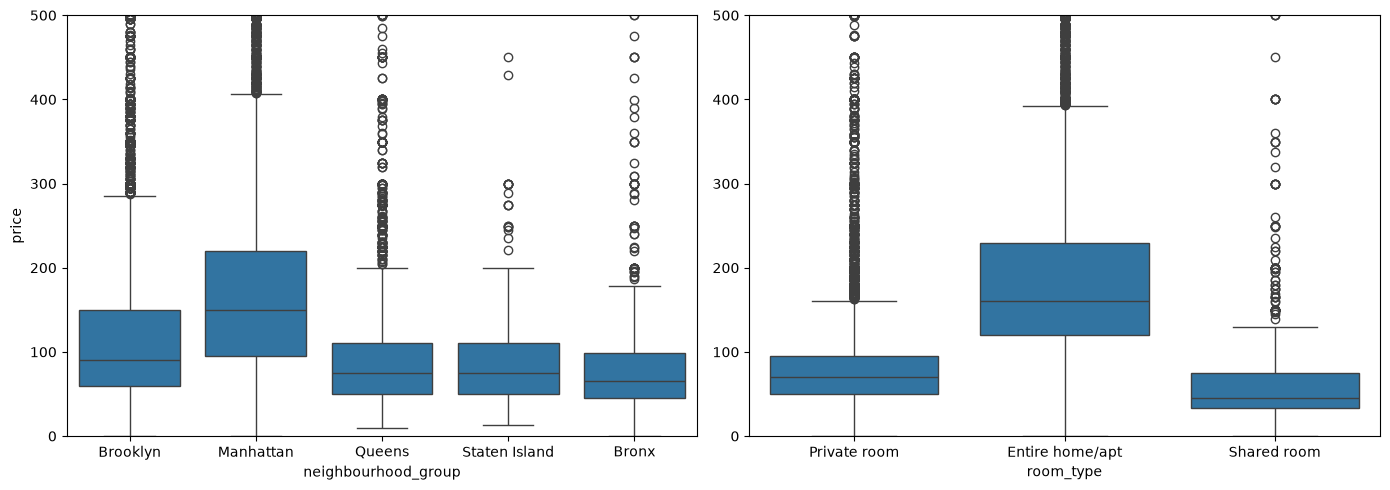

In [12]:
fig, axis = plt.subplots(1, 2, figsize = (14, 5))

sns.boxplot(ax = axis[0], data = total_data, x = "neighbourhood_group", y = "price")
sns.boxplot(ax = axis[1], data = total_data, x = "room_type", y = "price").set_ylabel(None)
axis[0].set_ylim(0, 500)
axis[1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

In [13]:
total_data.pivot_table(index = "neighbourhood_group", columns = "room_type", values = "price", aggfunc = "median")

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,53.5,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,191.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


#### Conclusions of the multivariate analysis

- **Room type by borough:** Manhattan is the only borough where entire homes
  are the majority (61%). In the Bronx, Queens, Brooklyn and Staten Island private
  rooms are the majority (50-60%). Shared rooms are below 6% everywhere.
- **Correlations with price:** the numeric variables have a weak relationship with
  `price` (|Pearson| <= 0.08 and |Spearman| <= 0.11), except `longitude`
  (Pearson -0.15, Spearman -0.44). The relationship with longitude is monotonic
  but not linear, which is why Spearman is much higher than Pearson: listings
  further west (Manhattan) are more expensive. `latitude` is weak (0.03 / 0.14).
- **Redundancy:** `number_of_reviews` and `reviews_per_month` are strongly related
  (Pearson 0.55, Spearman 0.71), so they carry similar information. Both are
  candidates to be reduced in the feature selection step.
- **Price drivers:** location and room type matter most. The median price is 191
  for an entire home in Manhattan against 100 in the Bronx or Staten Island, and
  entire homes cost roughly twice as much as private rooms in every borough
  (e.g. 145 vs 65 in Brooklyn). Both should be kept as predictors.
- **Coordinates:** `latitude` and `longitude` encode geography already captured
  by `neighbourhood_group`, but `longitude` adds finer information, so we keep it
  for now and decide in the feature selection step.

### Step 5: Feature engineering

#### Outliers
We count the listings that look like errors or belong to another market:
a price of 0, very expensive listings (above 500) and long-term rentals
(more than 30 minimum nights). The criteria are based on the domain, not on the
boxplot whiskers, which would remove too much from such skewed variables.

In [14]:
print("price == 0:", (total_data["price"] == 0).sum())
print("price > 500:", (total_data["price"] > 500).sum())
print("minimum_nights > 30:", (total_data["minimum_nights"] > 30).sum())

price == 0: 11
price > 500: 1044
minimum_nights > 30: 747


#### Missing values
Only `reviews_per_month` has nulls, and they are exactly the listings without
reviews, so the real value is 0 reviews per month. We fill them with 0 instead of
the median, which would invent activity that does not exist.

In [15]:
print(total_data.isnull().sum()[lambda s: s > 0])
total_data["reviews_per_month"] = total_data["reviews_per_month"].fillna(0)
print("nulls after:", total_data.isnull().sum().sum())

reviews_per_month    10052
dtype: int64
nulls after: 0


#### Remove the outliers
The filters are applied together, so the listings removed are fewer than the sum
of the counts above (some listings meet more than one criterion).

In [16]:
print("before:", total_data.shape)
total_data = total_data[(total_data["price"] > 0) & (total_data["price"] <= 500) & (total_data["minimum_nights"] <= 30)].reset_index(drop = True)
print("after:", total_data.shape)

before: (48895, 11)
after: (47125, 11)


#### Categorical variables
`neighbourhood` has 221 categories, too many for a numeric encoding, and its geography
is already captured by `neighbourhood_group`, `latitude` and `longitude`, so we drop it.
`neighbourhood_group` and `room_type` are encoded with numeric codes and the
mapping is saved to be able to interpret the results later. Note that numeric codes
suggest an order that does not exist; this is harmless for tree-based models but a
linear model could misinterpret it.

In [17]:
total_data.drop("neighbourhood", axis = 1, inplace = True)

In [18]:
mappings = {}
for column in ["neighbourhood_group", "room_type"]:
    codes, categories = pd.factorize(total_data[column])
    total_data[column] = codes
    mappings[column] = dict(enumerate(categories))
mappings

{'neighbourhood_group': {0: 'Brooklyn',
  1: 'Manhattan',
  2: 'Queens',
  3: 'Staten Island',
  4: 'Bronx'},
 'room_type': {0: 'Private room', 1: 'Entire home/apt', 2: 'Shared room'}}

#### Conclusions of the feature engineering

- **Outliers:** we removed the 11 listings with a price of 0, the 1,044 listings
  above 500 per night and the 747 listings with more than 30 minimum nights. Some
  listings met more than one criterion, so 1,770 rows (3.6%) were removed in total
  and 47,125 remain. We now model the typical short-stay market, and the model
  should not be used to predict luxury or long-term rentals.
- **Missing values:** the 10,052 nulls of `reviews_per_month` were listings without
  reviews, so they were filled with 0. No nulls remain.
- **Categorical variables:** `neighbourhood` (221 categories) was dropped because its
  geography is covered by `neighbourhood_group`, `latitude` and `longitude`.
  `neighbourhood_group` and `room_type` were encoded with numeric codes (the mapping
  is stored in `mappings`). These codes have no real order, so they are suitable
  for tree-based models but a linear model should use one-hot encoding instead.

### Step 6: Train/test split and feature scaling

#### Train/test split
We separate the predictors from the target (`price`) and keep 20% of the data for
testing. The split is done before scaling and before the feature selection, so that
nothing computed from the test set leaks into the training process.

In [19]:
from sklearn.model_selection import train_test_split

X = total_data.drop("price", axis = 1)
y = total_data["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape)

(37700, 9) (9425, 9)


#### Min-Max scaling
The scaler learns the minimum and maximum of each predictor from the train set only
and then applies them to both sets. The target `price` is not scaled. Test values
outside the train range can fall slightly outside [0, 1]; that is expected.

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), index = X_train.index, columns = X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index = X_test.index, columns = X.columns)

In [21]:
pd.concat([X_train_scaled.describe().round(2).loc[["min", "max"]].T.add_prefix("train_"),
           X_test_scaled.describe().round(2).loc[["min", "max"]].T.add_prefix("test_")], axis = 1)

,train_min,train_max,test_min,test_max
neighbourhood_group,0.0,1.0,0.00,1.00
latitude,0.0,1.0,0.11,0.98
longitude,0.0,1.0,0.13,0.98
room_type,0.0,1.0,0.00,1.00
minimum_nights,0.0,1.0,0.00,1.00
number_of_reviews,0.0,1.0,0.00,0.74
reviews_per_month,0.0,1.0,0.00,0.36
calculated_host_listings_count,0.0,1.0,0.00,1.00
availability_365,0.0,1.0,0.00,1.00


### Step 7: Feature selection

The selection is done with the train set only, so the test set does not influence
which variables we keep. We use the mutual information with `price` as the main
criterion because, unlike the linear F-test, it also detects non-linear relationships
(for example the borough, whose numeric codes have no real order). The F-score is
shown only for comparison. We keep the 6 variables with the highest mutual information.

In [22]:
from functools import partial
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression

mi_score = partial(mutual_info_regression, random_state = 42)
selector = SelectKBest(mi_score, k = 6)
selector.fit(X_train_scaled, y_train)

SelectKBest(k=6,
            score_func=functools.partial(<function mutual_info_regression at 0x78e856d0ef00>, random_state=42))

In [23]:
scores = pd.DataFrame({"mutual_info": selector.scores_.round(3),
                       "f_score": f_regression(X_train_scaled, y_train)[0].round(0)},
                      index = X_train_scaled.columns).sort_values("mutual_info", ascending = False)
scores

,mutual_info,f_score
room_type,0.305,9730.0
longitude,0.157,3619.0
calculated_host_listings_count,0.147,1063.0
latitude,0.130,191.0
neighbourhood_group,0.083,6.0
minimum_nights,0.047,120.0
availability_365,0.034,353.0
reviews_per_month,0.017,84.0
number_of_reviews,0.013,86.0


In [24]:
selected = X_train_scaled.columns[selector.get_support()]
X_train_sel = X_train_scaled[selected]
X_test_sel = X_test_scaled[selected]
print(list(selected))

['neighbourhood_group', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'calculated_host_listings_count']


#### Conclusions of the feature selection

- **Selected variables:** `room_type` (mutual information 0.305), `longitude` (0.157),
  `calculated_host_listings_count` (0.147), `latitude` (0.130), `neighbourhood_group`
  (0.083) and `minimum_nights` (0.047). Location and room type clearly dominate.
- **Discarded variables:** `availability_365` (0.034), `reviews_per_month` (0.017) and
  `number_of_reviews` (0.013) have very little relation with `price`. The two review
  variables are also correlated with each other, so they add no distinct information.
- **Weakest kept variable:** `minimum_nights` is far below the first five and was
  kept only because we decided to retain 6 variables; it is the first candidate to
  drop if the model overfits.
- **Linear vs non-linear:** `neighbourhood_group` has a very low F-score (6) but a
  clear mutual information (0.083), confirming that its numeric codes hide a
  non-linear relationship that the linear test cannot see.
- **Limitation:** mutual information scores each variable separately, so it does not
  detect redundancy. `latitude`, `longitude` and `neighbourhood_group` partly
  describe the same geography.
- The selector was fitted on the train set only and the same columns were applied
  to the test set.

### Step 8: Save the processed data
The processed train and test sets (the 6 selected and scaled predictors plus the
unscaled target `price`) are saved in `data/processed`. The `data` folder is listed in
`.gitignore`, so the data is not uploaded to the repository.

In [25]:
train = X_train_sel.copy()
train["price"] = y_train
test = X_test_sel.copy()
test["price"] = y_test

train.to_csv("../data/processed/train.csv", index = False)
test.to_csv("../data/processed/test.csv", index = False)
print(train.shape, test.shape)

(37700, 7) (9425, 7)
